In [1]:
import gc

# Clear GPU memory
import cupy as cp
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

# Clear CPU memory
gc.collect()

import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
dt = 10     # Time step
force_backend = "cuda12x"  # Force GPU

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-8  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}



print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)



Creating GenerateEMRIWaveform class...


In [53]:


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.95
p0 = 3.7
e0 = 0.2
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.0
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.0

In [54]:
traj = EMRIInspiral(**inspiral_kwargs)
amp = AmpInterpKerrEccEq(**amplitude_kwargs) 
interpolate_mode_sum = InterpolatedModeSum(**sum_kwargs)
ylm_gen = GetYlms(**Ylm_kwargs)


In [64]:
waveform_1yr = waveform_gen(m1, m2, a, p0, e0, xI0, dist, 
                            qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                            T=1/12, dt=dt)


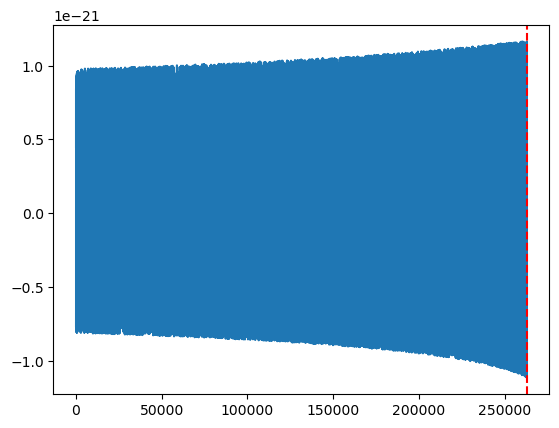

In [65]:
plt.plot(waveform_1yr.real.get())
# plt.xlim(len(waveform_1yr.real.get())-1000, len(waveform_1yr.real.get()))
plt.axvline(x=1/12*YRSID_SI/dt, color='r', linestyle='--', label='1 year')
plt.show()

In [66]:
gwf = GWfuncs.GravWaveAnalysis(1/12,10)

In [67]:
gwf.SNR(gwf.freq_wave(waveform_1yr))

array(44.14786595)

In [59]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta, phi


(2.3129424767905524, -1.5707963267948966)

In [60]:
# Num of traj points
# NOTE: fiddle here
T=1/12
N_traj = int(5e3)
# Time steps
delta_T = T * YRSID_SI / N_traj
delta_T

525.9691627257598

In [50]:
# Getting the trajectory etc
(t, p, e, x, Phi_phi, Phi_theta, Phi_r) = traj(
    m1, m2, a, p0, e0, xI0, T=T, dt=delta_T, 
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, 
    upsample=True)
teuk_modes = amp(a, p, e, x)
ylms = ylm_gen(amp.unique_l, amp.unique_m, theta, phi).copy()[amp.inverse_lm]


In [52]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj,1/12, [m1,m2,a,e0,xI0])

3.6846165873453907